# Seams, poles, islands, colour — the measurements

Companion of `seams-poles-islands-colour.md`. Every table here is read from `data/` (written by the probes of this branch) or computed from the formulas the code uses, quoted with their place. Nothing is rendered here.

- `data/synthetic-seams.csv`, `data/scenes-measured.txt` — `cargo test --release -p tuile-film-native --test exploration -- --nocapture --test-threads 1`
- `data/paris-sse{16,2}-shared-edges.csv` — `cargo run --release -p tuile-film --example seam_survey -- <pack> <csv> 1 24` on the two packs of the Paris orbit (tables only, no tile read)

Method, each time: what is supposed (plan), what was run (do), what the numbers say (check), what follows (act).

In [1]:
import math, pandas as pd, numpy as np, matplotlib.pyplot as plt
pd.set_option('display.width', 200); pd.set_option('display.max_colwidth', 80)
R = 6378137.0
INK, MUTED, BAR = '#1f2933', '#6b7280', '#3b6ea5'
def bars(ax, labels, values, title, xlabel):
    ax.barh(labels, values, color=BAR, height=0.6)
    ax.set_title(title, loc='left', color=INK, fontsize=11); ax.set_xlabel(xlabel, color=MUTED)
    for s in ('top','right','left'): ax.spines[s].set_visible(False)
    ax.tick_params(colors=MUTED, length=0); ax.grid(axis='x', color='#e5e7eb'); ax.set_axisbelow(True)
    for y, v in enumerate(values): ax.text(v, y, f' {v:g}', va='center', color=INK, fontsize=9)

## 1. Seams

**Supposed.** (H1) a tile cut from an ancestor's terrain is drawn with no skirt (`tuile-terrain/src/upsample.rs:233`, `edges` left empty, and `append_skirts` skips an edge of fewer than two vertices); (H2) tiles cut from *one* terrain tile agree along their shared edges whatever their levels, so the holes are where two *different* terrain tiles meet and at least the higher side is cut; (H3) a skirt on cut tiles closes them.

**Run.** Two made-up level-13 terrain tiles over the same relief, each on its own grid (32 and 20 spacings), drawn through the film's own path (`upsample` → `to_decoded` → `FilmGpu`), 1920×1080, 4 samples a pixel, an eye 600 m over the ground beside their shared meridian.

In [2]:
s = pd.read_csv('data/synthetic-seams.csv').drop(columns='picture')
print(open('data/scenes-measured.txt').read().split('\n')[4])
s.pivot_table(index=['scene','eye'], columns='variant', values=['sky_pixels','touched_pixels'])

source tiles of level 13 part along their shared meridian by 5.61 m at most, 1.53 m on average; a level-13 skirt is 47.8 m deep, a level-14 one 23.9, level 15 11.9, level 16 6.0


sky_pixels                                             touched_pixels                                         
variant                                cut-tiles-skirted cut-tiles-skirted-at-source-depth   main cut-tiles-skirted cut-tiles-skirted-at-source-depth   main
scene                         eye                                                                                                                           
one-surface                   eye-west               0.0                               0.0    0.0               0.0                               0.0    0.0
two-surfaces-neighbour-cut    eye-east               0.0                               0.0  361.0               0.0                               0.0  509.0
                              eye-west               0.0                               0.0  241.0               0.0                               0.0  378.0
two-surfaces-neighbour-itself eye-east               0.0                               0.0  361.0               0.0                               0.0  509.0
                              eye-west               0.0                               0.0    0.0               0.0                               0.0    0.0

**Check.** H2 holds: one surface at levels 14, 15 and 16 mixed shows no pixel of sky. Two surfaces show 241 to 361 whole pixels (378 to 509 touched) for steps of 1.5 m on average and 5.6 m at most — the size of the film's own defect (about 300 pixels in frame 4500 of the 577d film). A neighbour drawn as itself, with its 48 m skirt, closes only the steps where *it* is the higher side: seen from its side, the cut tile's higher edges stay open (361). H3 holds: with edge lists on cut tiles every count is 0, at the tile's own depth already.

What the depth has to cover, by level (`skirt_height`, `tuile-terrain/src/mesh.rs:132`: five geometric errors, width × R / 256 each):

In [3]:
lv = pd.DataFrame({'level': range(8, 20)})
lv['tile width at the equator, m'] = (math.pi / 2**lv.level * R).round(1)
lv['skirt depth, m'] = (lv['tile width at the equator, m'] * 0.25 / 64 * 5).round(2)
lv.set_index('level').T

level,8,9,10,11,12,13,14,15,16,17,18,19
"tile width at the equator, m",78271.50,39135.80,19567.90,9783.90,4892.00,2446.00,1223.00,611.50,305.70,152.90,76.40,38.20
"skirt depth, m",1528.74,764.37,382.19,191.09,95.55,47.77,23.89,11.94,5.97,2.99,1.49,0.75


A cut tile's surface is its ancestor's: its error is the ancestor's, not its own level's. A level-19 tile cut from level 13 would be given a 0.75 m skirt for a surface whose neighbour may stand 5 m off. The depth that matches is the *source* level's (47.8 m at 13).

**How much of a real film is cut tiles.** The Paris orbit, two bakes (screen-space error 16 and 2), frames 1 and 24, from the packs' tables:

In [4]:
def survey(name):
    d = pd.read_csv(f'data/{name}-shared-edges.csv')
    d['a_cut'] = d.a_source < d.a_level; d['b_cut'] = d.b_source < d.b_level
    kind = np.select([~d.a_cut & ~d.b_cut, d.same_surface.eq(1), d.a_cut & d.b_cut],
                     ['both from their own terrain (skirted)', 'both cut, from one terrain tile (agree)', 'both cut, from two terrain tiles (no skirt either side)'],
                     'one cut, one skirted')
    d['kind'] = kind; d['jump'] = (d.a_level - d.b_level).abs(); d['imagery jump'] = (d.a_imagery - d.b_imagery).abs()
    return d
p16, p2 = survey('paris-sse16'), survey('paris-sse2')
pd.DataFrame({'sse 16': p16.kind.value_counts(), 'sse 2': p2.kind.value_counts()}).fillna(0).astype(int)

,sse 16,sse 2
kind,,
"both cut, from one terrain tile (agree)",211,1609
"both cut, from two terrain tiles (no skirt either side)",5,158
both from their own terrain (skirted),141,847
"one cut, one skirted",24,30


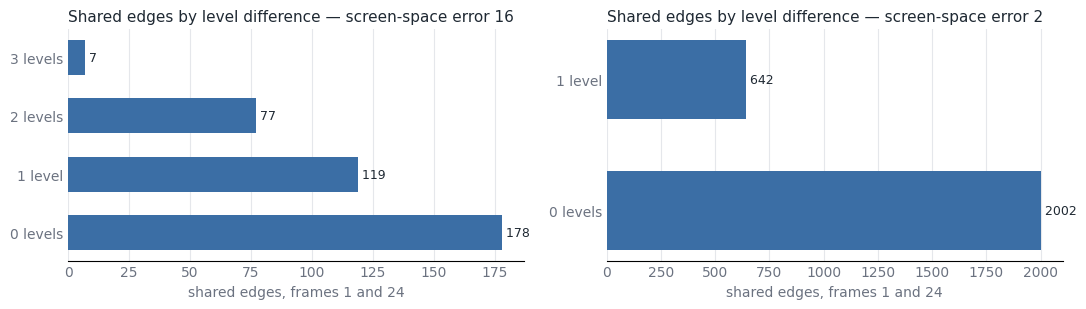

terrain levels the surfaces are from, sse 2: [3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
widest jump: sse 16 = 3 levels; sse 2 = 1


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, (d, t) in zip(axes, [(p16, 'screen-space error 16'), (p2, 'screen-space error 2')]):
    c = d.jump.value_counts().sort_index()
    bars(ax, [f'{k} level' + ('s' if k != 1 else '') for k in c.index], c.values, f'Shared edges by level difference — {t}', 'shared edges, frames 1 and 24')
plt.tight_layout(); plt.show()
print('terrain levels the surfaces are from, sse 2:', sorted(set(p2.a_source) | set(p2.b_source)))
print('widest jump: sse 16 =', p16.jump.max(), 'levels; sse 2 =', p2.jump.max())

**Check.** In these packs no surface is from terrain finer than level 13: every tile of levels 14 to 19 is cut, so nothing drawn near the camera has a skirt. Edges between tiles cut from two terrain tiles — the open kind — are few (5 of 381 at a screen-space error of 16, 158 of 2 644 at 2) and they are exactly the straight lines of the level-13 grid nearest the camera. Edges with a skirted tile on one side only (24 and 30) are open from one side. No rule in `tuile-core/src/traversal.rs` bounds the level difference between neighbours; what is measured is at most one level in the precise bake and up to three in the coarse one.

**Act.** Smallest correct change: give `upsample` its four edge lists and hang the skirt at the source level's depth. Judged by: the synthetic counts above at 0, and `--seams` on a real film (`open_px_facing` summed, and the picture's own count under `TUILE_PROBE_HOLES`).

### The light line of frame 4500 (577d), bottom left

Measured on the pictures in `videos/` (not in the repository): 172 pixels on a straight line (slope −0.06) along the level 15/16 boundary.

| picture | the line, sRGB mean | ground 2–4 px around |
|---|---|---|
| sun at 250°, 12° — no haze | 80, 92, 76 | 46, 62, 55 |
| same, with haze | 81, 93, 78 | 51, 66, 60 |
| the default look (sun on the Earth's axis) | 50, 62, 54 | 51, 69, 61 |

It is there without haze, at the same value: the haze did not make it (it adds 1.3 to the line where it adds 5 to the ground around, because the resolve leaves ground it cannot place alone). Under the default sun it is as dark as the ground; under a low sun from the west-south-west it is 0.8 stop lighter. The hole painter settles it on the real frame: 171 of the 172 pixels are touched by a hole. It is a gap, and what shows through is the far side where the low sun lights it.

## 1b. Seams on a real frame: frame 4500 of the 577d film

**Supposed.** Whatever leaves the film's holes is in the meshes of the tiles that frame draws: two neighbours that do not put their shared edge at the same place and the same height. Candidates: two levels of the source's data; quantisation against two height ranges; a vertex not at the same place along the edge; a chord against an arc between sparse vertices; rounding to `f32` about two origins.

**Run.** The frame rendered from the tile store by the exploration's renderer, `--seams` (the seam meter: every shared edge of the 253 tiles drawn, each side's surface read from the mesh as built, in f64 from its origin) with the hole painter on; then the permanent log of branch `feat/seam-residual` on the same frame, which reads the meshes as the GPU is handed them. `a_source` / `b_source` is the level of the terrain tile a surface is from: lower than the tile's own level, it was cut from an ancestor and — on `main` — has no skirt.

In [6]:
e = pd.read_csv('data/577d-f4500-shared-edges-main.csv')
e['a_cut'] = e.a_source < e.a_level; e['b_cut'] = e.b_source < e.b_level
def kind(r):
    if not r.a_cut and not r.b_cut:
        return 'both from their own terrain, one level' if r.a_level == r.b_level else 'both from their own terrain, two levels'
    if r.a_cut and r.b_cut:
        return 'both cut, from terrain of one level' if r.a_source == r.b_source else 'both cut, from terrain of two levels'
    return 'one cut from an ancestor, one from its own'
e['kind'] = e.apply(kind, axis=1)
near = e[e.distance_m < 30000]
print(len(e), 'shared edges in the frame;', len(near), 'within 30 km of the eye; terrain levels the surfaces are from:', sorted(set(near.a_source) | set(near.b_source)))
near.groupby('kind').agg(edges=('kind', 'size'), step_median_m=('step_max_m', 'median'), step_largest_m=('step_max_m', 'max'),
    placement_apart_m=('lateral_max_m', 'max'), open_edges=('open_max_m', lambda s: int((s > 0).sum())),
    open_largest_m=('open_max_m', 'max'), open_px_facing_the_eye=('open_px_facing', 'sum')).round(3)

513 shared edges in the frame; 388 within 30 km of the eye; terrain levels the surfaces are from: [10, 11, 12, 13, 14, 15, 16, 17]


,edges,step_median_m,step_largest_m,placement_apart_m,open_edges,open_largest_m,open_px_facing_the_eye
kind,,,,,,,
"both cut, from terrain of one level",109,0.000,0.033,0.000,10,0.033,2.06
"both cut, from terrain of two levels",24,0.804,2.180,0.007,24,2.180,0.00
"both from their own terrain, one level",127,0.003,0.660,0.002,0,0.000,0.00
"both from their own terrain, two levels",88,1.357,51.217,0.266,0,0.000,0.00
"one cut from an ancestor, one from its own",40,0.000,3.125,0.010,15,3.125,468.82


In [7]:
cols = ['a_level','a_x','a_y','a_source','a_skirted','b_level','b_x','b_y','b_source','b_skirted','length_m','distance_m','step_max_m','open_max_m','open_px_facing']
e[e.open_px_facing > 0.5][cols].sort_values('open_px_facing', ascending=False).round(2)

,a_level,a_x,a_y,a_source,a_skirted,b_level,b_x,b_y,b_source,b_skirted,length_m,distance_m,step_max_m,open_max_m,open_px_facing
378,16,64485,51889,16,1,15,32243,25944,14,0,306.43,1174,0.98,0.98,143.69
375,16,64485,51886,16,1,15,32243,25943,14,0,306.90,1139,1.73,1.36,115.75
379,15,32242,25945,15,1,15,32243,25945,14,0,614.36,1444,1.10,1.10,85.97
24,15,32244,25943,14,0,15,32245,25943,15,1,611.65,1686,3.12,3.12,39.81
26,15,32244,25945,14,0,15,32245,25945,15,1,612.44,1910,1.98,1.93,33.28
320,15,32243,25942,15,1,15,32243,25943,14,0,374.11,1319,2.81,1.75,21.98
377,16,64485,51888,16,1,15,32243,25944,14,0,307.57,1091,1.95,0.95,13.34
25,15,32244,25944,14,0,15,32245,25944,15,1,611.72,1700,2.18,0.97,11.82
376,16,64485,51887,16,1,15,32243,25943,14,0,308.89,1083,1.89,0.12,2.49
70,15,32243,25943,14,0,15,32244,25943,14,0,611.53,1361,0.01,0.01,0.88


**Check.** Measured on the pictures: 686 pixels of the frame are touched by a hole (the painter), and the meter's openings facing the eye come to 471 px² — the same seams, the meter knowing nothing of partial coverage.

- Same level, own terrain: 3 mm at the median. **The source's tiles of one level coincide.** Quantisation and vertex placement are at that grain; not the cause.
- Cut from terrain of one level: centimetres — the chord against the arc at a vertex made by cutting. Not the cause.
- Placement: a centimetre near the eye in every class. **The two sides are in the same place; they differ in height.**
- Two levels of data along one line: 1.4 m at the median, 51 m at most. That is the source's own disagreement between its levels. Where both sides have skirts it is hidden; **where one side is cut from an ancestor it has none, and all fifteen openings facing the eye are there** — six level-15 tiles the source does not have (15/32243–32244/25943–25945), cut from level 14, against neighbours from level-15 and level-16 terrain.

The permanent log, same frame, from the meshes as the GPU gets them (`f32` about each tile's origin):

In [8]:
r = pd.read_csv('data/577d-f4500-residuals.csv'); display(r.T.rename(columns={0: 'frame 4500'}))
p = pd.read_csv('data/577d-f4500-residual-pairs.csv')
shown = p[p.in_picture == 1].copy()
shown['sides'] = shown.apply(lambda q: ('cut' if q.a_source < q.a_level else 'own') + ' | ' + ('cut' if q.b_source < q.b_level else 'own'), axis=1)
shown[['a_level','a_x','a_y','a_source','b_level','b_x','b_y','b_source','sides','residual_m','height_m','horizontal_m','residual_px','picture_x','picture_y']].round(2)

,frame 4500
frame,4.500000e+03
tiles,2.530000e+02
shared,5.130000e+02
over,1.490000e+02
over_in_picture,2.500000e+01
max_m,9.899884e+03
p50_m,8.000000e-03
p99_m,7.638721e+03
max_px,3.461000e+00
p50_px,1.000000e-03


,a_level,a_x,a_y,a_source,b_level,b_x,b_y,b_source,sides,residual_m,height_m,horizontal_m,residual_px,picture_x,picture_y
6,15,32243,25942,15,15,32243,25943,14,own | cut,2.78,2.74,0.43,2.94,1692.0,753.2
11,13,8063,6485,13,12,4032,3242,12,own | own,12.18,12.16,0.77,2.76,1174.5,43.4
12,14,16123,12972,14,13,8062,6486,13,own | own,5.82,5.68,1.29,2.75,758.7,184.5
13,14,16123,12970,14,13,8062,6485,13,own | own,6.46,-6.46,0.03,2.72,1625.7,263.3
24,15,32244,25943,14,15,32245,25943,15,cut | own,3.11,3.09,0.35,2.34,1349.5,393.2
26,14,16123,12971,14,13,8062,6485,13,own | own,5.30,5.28,0.41,2.33,1482.4,250.0
27,13,8063,6487,13,12,4032,3243,12,own | own,12.15,11.70,3.28,2.31,16.4,17.8
28,16,64485,51887,16,15,32243,25943,14,own | cut,1.86,1.84,0.32,2.27,1146.1,844.9
29,16,64485,51888,16,15,32243,25944,14,own | cut,1.89,1.84,0.44,2.26,699.9,861.7
32,13,8063,6486,13,12,4032,3243,12,own | own,9.72,-9.60,1.54,2.22,890.0,32.9


**Check.** 149 of 513 shared edges are over a quarter of a pixel, 25 of them in the picture (the file keeps the worst 64 of the frame, 15 of them in the picture). The residual is almost all height. The rows with a cut side are the film's holes, at the places of the dark hairs: around (1692, 753), (1554, 845), (1146, 845), (700, 862), (1350, 393). The rows with two own sides, 5 to 12 m at levels 12 to 14, are what skirts hide today. Narrowing to `f32` adds nothing that shows: same-level pairs stay at millimetres.

With skirts on cut tiles (the local safety net): 0 pixels touched by a hole; 722 pixels of the frame change, the 686 and 36 beside them. The residual above does not change — the edges still do not coincide.

**Act.** The step is between two levels of data, so making the edges coincide means one side taking the other's edge, chosen by what is drawn across it: at selection. See the document, section 1.5. Judged by this log at 0 over tolerance, with no skirt.

## 2. Poles

**Supposed.** Imagery on a web-mercator grid ends at 85.0511°. The loader says the top row of each imagery level reaches the pole (`to_the_pole`, `tuile-planetary/src/lib.rs:275`) and `ImageryLayer::substituted` (`tuile-core/src/raster.rs:947`) then lays the row's texture *linearly* over that taller rectangle — a stretch, not a clamp. The row is thinner at each level, so the stretch grows and the same feature lands at a different latitude at each level.

In [9]:
def row0_south(level): return math.degrees(math.atan(math.sinh(math.pi * (1 - 2 / 2**level))))
N = 85.0511287798
rows = []
for L in range(2, 20):
    s = row0_south(L); k = (90 - s) / (N - s)
    drawn = lambda lat: 90 - (N - lat) * k
    rows.append({'imagery level': L, 'top row from, °': round(s, 4), 'stretched ×': round(k, 1),
                 'ground of 85.00° drawn at, °': round(drawn(85.0), 2) if s < 85.0 else None,
                 'moved north by, km': round((drawn(85.0) - 85.0) * 111.2) if s < 85.0 else None})
pole = pd.DataFrame(rows).set_index('imagery level'); pole

,"top row from, °",stretched ×,"ground of 85.00° drawn at, °","moved north by, km"
imagery level,,,,
2,66.5133,1.3,89.94,549.0
3,79.1713,1.8,89.91,546.0
4,82.6763,3.1,89.84,538.0
5,83.9793,5.6,89.71,524.0
6,84.5414,10.7,89.45,495.0
7,84.8025,20.9,88.93,437.0
8,84.9283,41.3,87.89,321.0
9,84.9901,82.1,85.80,89.0
10,85.0207,163.7,NaN,NaN


In [10]:
print(''.join(open('data/scenes-measured.txt').readlines()[0:4]))
print(''.join(open('data/scenes-measured.txt').readlines()[6:10]))

imagery level 4: its top row holds 82.676° to 85.051° and is laid over 82.676° to 90°, stretched 3.1 times; 4 layers on the terrain tile
  the line of 85° is drawn from 89.71° to 89.98°
imagery level 7: its top row holds 84.802° to 85.051° and is laid over 84.802° to 90°, stretched 20.9 times; 256 layers on the terrain tile
  the line of 85° is drawn from 87.69° to 89.98°

polar tile 3/8/7 on a 8×8 grid: 8 of 128 surface triangles have no area (under 1 m²), 8 of 64 skirt triangles; its skirt is 48920 m deep, as at the equator, on a tile 959 km wide at its south edge and nothing at its north
  a north-skirt vertex of the meridian 0.00° comes out at longitude -180.00°, latitude 89.99775°
  1000 m over the pole itself: ecef_to_geodetic gives latitude 135.0000°, height 2645150.6 m
  1000 m over a millimetre off the axis: ecef_to_geodetic gives latitude 90.0000°, height 1000.0 m



**Check.** The composed drape of a polar terrain tile (picture `explore-pole-drape-truth-level4-level7.png`: what is there, level 4, level 7) agrees with the formula: the line of 85° is drawn between 89.7° and the pole with level-4 imagery and smeared from 87.7° to the pole with level 7. Above 85.05° nothing is black, green or bare: it is the top row's ground, displaced by up to 550 km, and two neighbouring tiles draped at two imagery levels do not show the same ground. At the pole itself the mesh's north row collapses to a point (8 surface and 8 skirt triangles of no area on an 8×8 grid), the north skirt wraps over the pole onto the opposite meridian, and the skirt is 48.9 km deep. `ecef_to_geodetic` on the axis itself returns 135° and 2 645 km: a camera exactly over a pole gets a wrong near plane, and a wrong frame for `--sun` and the haze; a millimetre off the axis it is right.

**Act.** Clamp instead of stretch (the row's texture over its own rectangle, its last texel row over what lies beyond), or drape the cap from a geographic source; guard the axis in `ecef_to_geodetic`. Judged by: the line of 85° drawn at 85° at every level in the same picture.

## 3. Islands and open sea

**Supposed.** Over sea a terrain source holds coarse tiles of few triangles. A straight edge between two vertices sags below the ellipsoid by `L² / 8R`; a fine neighbour stands on the ellipsoid; the fine tile is the higher side, so its skirt is what must cover the sag — and a fine tile cut from an ancestor has none.

In [11]:
rows = []
for L in range(4, 13):
    w = math.pi / 2**L * R
    r = {'coarse level': L, 'edge, km': round(w / 1000, 1)}
    for n in (1, 4, 16, 64):
        r[f'sag with {n} segment' + ('s' if n > 1 else '') + ', m'] = round((w / n)**2 / (8 * R), 2)
    r['its own skirt, m'] = round(w * 5 / 256, 1)
    for k in (1, 2, 4, 6):
        r[f'skirt of a neighbour {k} finer, m'] = round(w / 2**k * 5 / 256, 1)
    rows.append(r)
pd.DataFrame(rows).set_index('coarse level')

,"edge, km","sag with 1 segment, m","sag with 4 segments, m","sag with 16 segments, m","sag with 64 segments, m","its own skirt, m","skirt of a neighbour 1 finer, m","skirt of a neighbour 2 finer, m","skirt of a neighbour 4 finer, m","skirt of a neighbour 6 finer, m"
coarse level,,,,,,,,,,
4,1252.3,30737.15,1921.07,120.07,7.50,24459.8,12229.9,6115.0,1528.7,382.2
5,626.2,7684.29,480.27,30.02,1.88,12229.9,6115.0,3057.5,764.4,191.1
6,313.1,1921.07,120.07,7.50,0.47,6115.0,3057.5,1528.7,382.2,95.5
7,156.5,480.27,30.02,1.88,0.12,3057.5,1528.7,764.4,191.1,47.8
8,78.3,120.07,7.50,0.47,0.03,1528.7,764.4,382.2,95.5,23.9
9,39.1,30.02,1.88,0.12,0.01,764.4,382.2,191.1,47.8,11.9
10,19.6,7.50,0.47,0.03,0.00,382.2,191.1,95.5,23.9,6.0
11,9.8,1.88,0.12,0.01,0.00,191.1,95.5,47.8,11.9,3.0
12,4.9,0.47,0.03,0.00,0.00,95.5,47.8,23.9,6.0,1.5


**Check (computed, not rendered).** With a single segment an edge, a level-8 sea tile sags 120 m; a skirted neighbour four levels finer hangs 95 m and leaves 25 m open, and a cut neighbour leaves all 120 m. With 16 segments or more the sag is under half a metre at every level and any skirt covers it. So whether coasts open depends on one number this exploration could not read: how many vertices the source's sea tiles have along an edge. The level difference between a coast's tiles and the sea's is bounded by no rule (section 1: up to three levels measured inland at a coarse error; no coast was measured). Heights are over the ellipsoid; the sea surface is the geoid; nothing in the workspace knows the difference (no geoid anywhere), so the sea is drawn where the source's tile puts it.

**Act.** Read twenty sea tiles of the store at levels 6 to 10 and count their edge vertices (a store read, no source asked); only if the count is low does a coast need more than section 1's skirts.

## 4. Colour

**Supposed.** A bake writes into every tile of a pack the colour the interactive viewer shows where no imagery layer reaches (`UNCOVERED_GROUND`, `tuile-planetary/src/lib.rs:194`, kept by `bake.rs:383`). The viewer draws layers *over* it; the film's resolve *multiplies* the composed drape by it (`resolve.wgsl`: `var base = tile.factor.rgb; … base *= texture`).

In [12]:
print(open('data/scenes-measured.txt').readlines()[5])
f = np.array([0.16, 0.20, 0.24]); st = np.log2(f)
pd.DataFrame({'factor': f, 'stops': st.round(2), 'stops against green': (st - st[1]).round(2)}, index=['R', 'G', 'B'])

a grey drape (120, 120, 120) under the default look: factor white shows [142, 146, 149], the pack's slate (0.16, 0.20, 0.24) shows [59, 68, 76] — -2.63 / -2.31 / -2.06 stops (R G B)



,factor,stops,stops against green
R,0.16,-2.64,-0.32
G,0.20,-2.32,0.00
B,0.24,-2.06,0.26


**Check.** Both Paris packs carry (0.16, 0.20, 0.24) on every tile (1 313 and 182 tiles read). On the GPU a grey drape comes out 2.63 / 2.31 / 2.06 stops darker (R, G, B) than under a white factor: the whole film is 2.3 stops down and tinted — red 0.32 stop under green, blue 0.26 over. The look's exposure was set on films rendered this way, so it carries the 2.3 stops; nothing carries the tint. It is the same for every tile, so it makes no step between tiles; it shifts every measurement against a reference layer by the same amount, and a calibration taken at a dose of 0.3 undoes three tenths of it.

**Act.** Not decided here. The measurement that would judge any change: the checkerboard and the triptych of `--calibrate` against the reference layer, before and after, coarse level and a fine one (16+), opened.